# EDA and data cleaning

In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os

# 1. Get the directory of the current notebook
notebook_dir = os.path.abspath('')

# 2. Go up two levels to reach the 'src' root directory
src_root = os.path.abspath(os.path.join(notebook_dir, '..'))

# 3. Target the 'utils' folder exactly
utils_path = os.path.join(src_root, 'utils')

# 4. Append to sys.path if it's not already there
if utils_path not in sys.path:
    sys.path.append(utils_path)

#  FORCE CACHE CLEAR: Manually evict the old module version from Python's memory
if 'eda_and_data_cleaning' in sys.modules:
    del sys.modules['eda_and_data_cleaning']

print(f"Added to path: {utils_path}")

# 5. Import your functions seamlessly
from eda_and_data_cleaning import (
    summarize_dataset_structure, 
    drop_missing_landmark_frames, 
    plot_feature_variance_by_class, 
    plot_feature_collinearity_matrix, 
    plot_signal_stability_over_time
)

Added to path: d:\YogAi_Models_Refactor\src\utils


In [2]:

raw_chair_df = summarize_dataset_structure("../../data/processed/engineered_features/chair_pose/chair_pose_features.csv")


       RESEARCH COMPREHENSIVE PROFILE: ../../data/processed/engineered_features/chair_pose/chair_pose_features.csv               
 DATASET DIMENSIONS:
   - Total Recorded Frames (Rows): 2933
   - Total Columns: 11
   - Biomechanical Features Detected (8): ['is_left_facing', 'camera_knee_flexion_angle', 'camera_torso_hip_knee_angle', 'camera_shoulder_arm_angle', 'camera_wrist_shoulder_vertical_delta', 'camera_hip_knee_vertical_delta', 'camera_shoulder_ankle_horizontal_offset', 'camera_knee_ankle_horizontal_overhang']

 FEATURE DESCRIPTIVE STATISTICS (ANGLES/DISTANCES):


,mean,std,min,max
is_left_facing,0.112172,0.315632,0.000000,1.000000
camera_knee_flexion_angle,125.980577,14.152116,48.651696,172.450148
camera_torso_hip_knee_angle,121.230371,18.335746,8.214866,174.267513
camera_shoulder_arm_angle,150.485590,27.943309,10.225804,179.509167
camera_wrist_shoulder_vertical_delta,0.572986,0.222879,0.002657,1.151805
camera_hip_knee_vertical_delta,0.459856,0.108178,0.059513,0.839238
camera_shoulder_ankle_horizontal_offset,0.147279,0.136969,0.000112,1.798704
camera_knee_ankle_horizontal_overhang,0.198594,0.066561,0.002518,1.485769




 LABEL/CLASS DISTRIBUTION (Target Balance):
   - Class 'bent_forward': 750 frames (25.57%)
   - Class 'dropped_arms': 750 frames (25.57%)
   - Class 'shallow_squat': 750 frames (25.57%)
   - Class 'correct': 683 frames (23.29%)


📹 VIDEO SOURCE DISTRIBUTION (Data Diversity):
   - Total unique video sources: 69
   - Frames per top sources:
source_id
correct_7.mp4         251
correct_11.mp4        184
bent_forward_1.mp4    150
bent_forward_2.mp4    150
bent_forward_3.mp4    150

🔍 LANDMARK DROP/MISSING VALUE PROFILE:
   - Phenomenal! Zero missing values detected in the raw dataset.



In [3]:

# Run Targeted Structural Cleaning
cleaned_chair_df = drop_missing_landmark_frames(raw_chair_df)


[CLEANING] Dropped 0 frames due to incomplete landmark tracking.
[CLEANING] Remaining stable frames: 2933


In [ ]:
# # Count before filtering
# initial_count = len(cleaned_chair_df)

# # Apply the outlier filter
# cleaned_chair_df = cleaned_chair_df[cleaned_chair_df['stance_width_normalized'] < 5.0]

# # Count after filtering
# final_count = len(cleaned_chair_df)
# dropped_count = initial_count - final_count

# # Print the breakdown nicely
# print(f"--- Stance Width Outlier Removal Summary ---")
# print(f"Initial row count: {initial_count}")
# print(f"Rows dropped (stance width >= 5.0): {dropped_count}")
# print(f"Final cleaned row count: {final_count}")
# print(f"--------------------------------------------")

In [ ]:
# Drop rows where normalized stance width is unrealistically high (e.g., > 5.0)
# cleaned_chair_df = cleaned_chair_df[cleaned_chair_df['stance_width_normalized'] < 5.0]

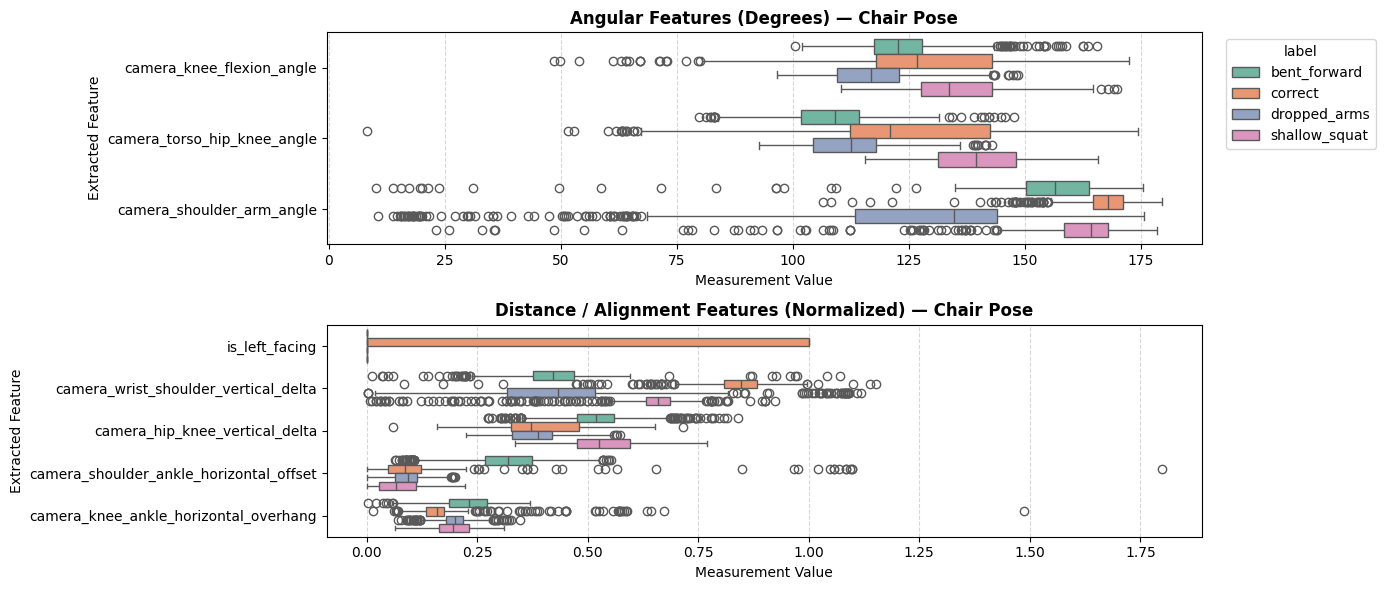

In [4]:

# Visualization
plot_feature_variance_by_class(cleaned_chair_df, pose_name="Chair Pose")


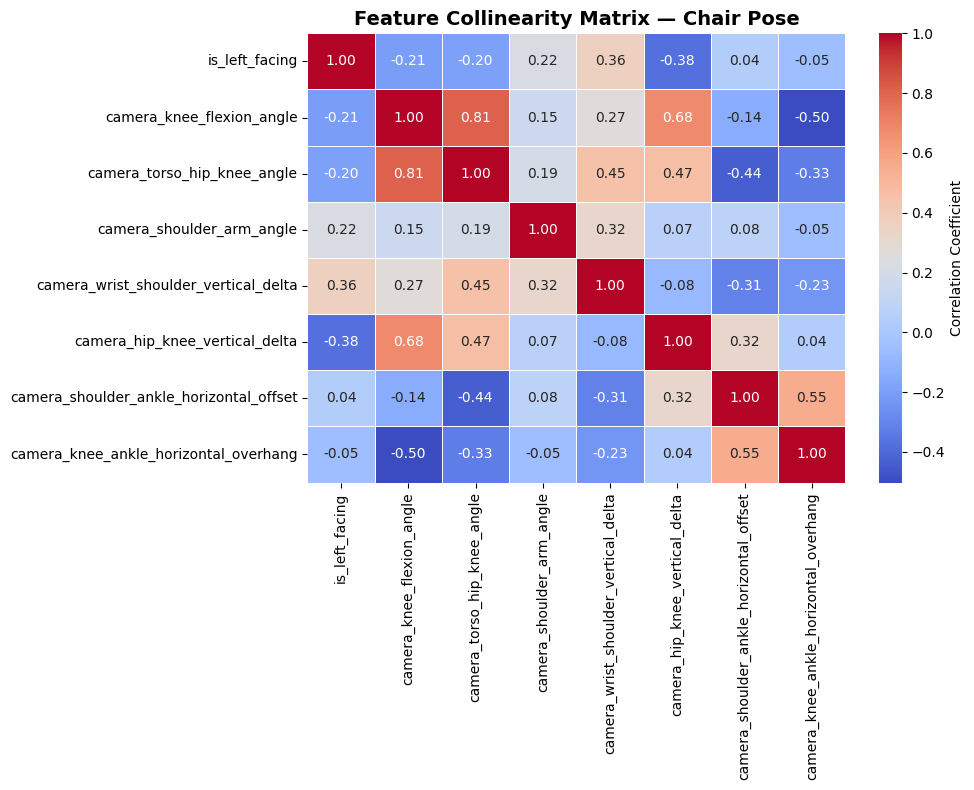

In [5]:
plot_feature_collinearity_matrix(cleaned_chair_df, pose_name="Chair Pose")

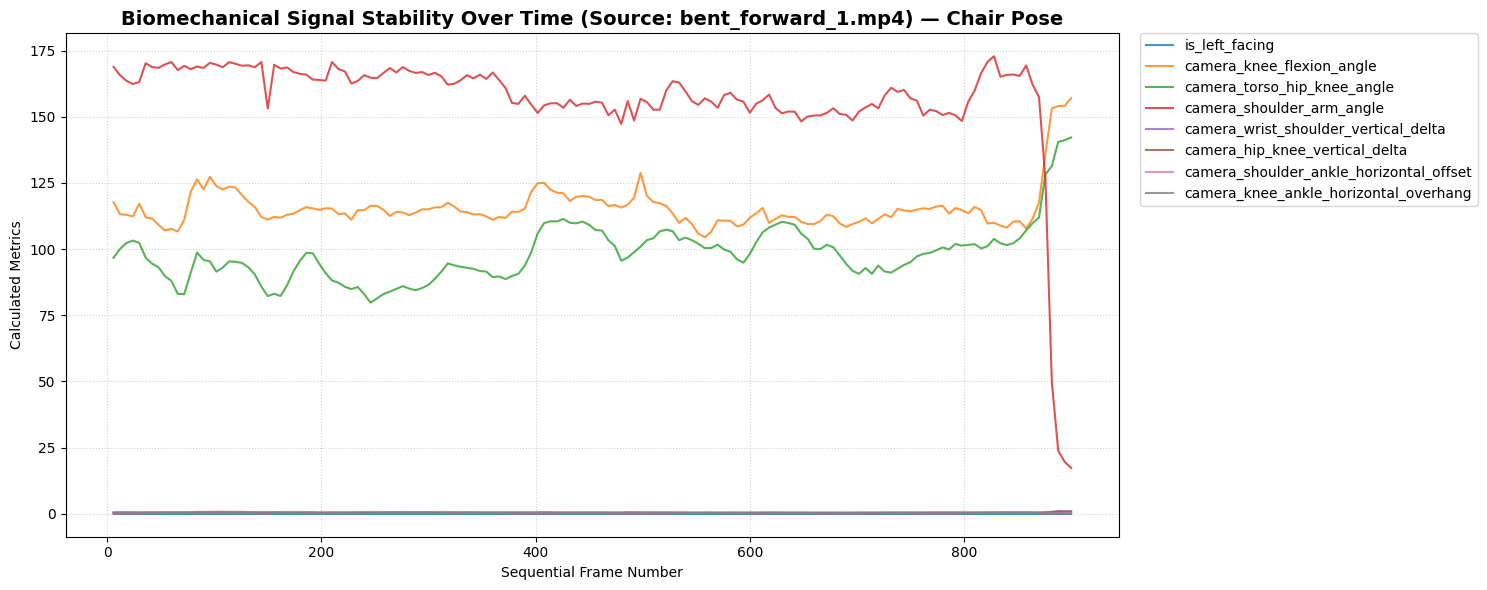

In [6]:
plot_signal_stability_over_time(cleaned_chair_df, pose_name="Chair Pose")
